
# ACH Risk & Payments Intelligence Analytics Project

## Overview
This notebook demonstrates an end-to-end risk analytics workflow aligned with the responsibilities of a Risk & Payments Intelligence Analyst role in fintech and payment processing environments.

The project highlights experience in:

- ACH payment risk analytics
- Fraud and loss trend analysis
- ML risk score evaluation
- Portfolio monitoring
- Cohort and behavioral analysis
- SQL-style data aggregation
- Python-based exploratory analytics
- Decision strategy evaluation
- Analytical automation workflows

The workflow simulates a production-style payments intelligence environment using Python, pandas, NumPy, and machine learning techniques commonly used in fintech risk analytics.



# Business Objective

The objective is to evaluate ACH payment decisioning performance and identify:

1. Drivers of payment losses
2. Risk patterns by customer segment
3. High-risk transaction cohorts
4. Performance of ML risk scores
5. Impact of approval thresholds on fraud losses
6. Operational opportunities to improve portfolio outcomes


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

pd.set_option("display.max_columns", None)

## Simulated ACH Transaction Dataset

In [2]:
n = 50000 # number of generated transactions

df = pd.DataFrame({
    "transaction_id": np.arange(n),
    "customer_age_days": np.random.exponential(400, n).astype(int), #the number of days since a customer account was created or first became active in the platform.
    "transaction_amount": np.random.gamma(2, 150, n), #the amount of the current ACH transaction being evaluated
    # Commonly engineered risk and behavioral features used in fintech, fraud detection, ACH risk analytics, and payment decisioning systems:
    "transactions_30d": np.random.poisson(6, n), # number of transactions performed by the customer in the last 30 days;
    "chargebacks_90d": np.random.poisson(0.3, n), # number of chargebacks, disputes, or returned ACH payments associated with the customer in the past 90 days;
    "bank_account_age_days": np.random.exponential(700, n).astype(int), # age of the linked bank account in days;
    "device_risk_score": np.random.uniform(0, 1, n), # risk score associated with the device used for the transaction;
    "velocity_score": np.random.uniform(0, 1, n), # measures how rapidly activity is occurring;
    "vendor_risk_score": np.random.uniform(0, 1, n), # risk score from external vendors or third-party data providers;
    "geo_risk_score": np.random.uniform(0, 1, n), # risk score based on geographic indicators.
})

risk_signal = (
    0.25 * df["device_risk_score"] +
    0.25 * df["velocity_score"] +
    0.25 * df["vendor_risk_score"] +
    0.15 * df["geo_risk_score"] +
    0.10 * (df["chargebacks_90d"] > 0).astype(int)
)

df["ml_risk_score"] = (risk_signal * 1000).clip(0, 999)

fraud_probability = (
    0.02 +
    0.15 * (df["ml_risk_score"] / 1000) +
    0.08 * (df["chargebacks_90d"] > 0).astype(int)
)

df["is_fraud"] = np.random.binomial(1, fraud_probability)

df["decision"] = np.where(df["ml_risk_score"] > 700, "DECLINE", "APPROVE")

df["loss_amount"] = np.where(
    df["is_fraud"] == 1,
    df["transaction_amount"] * np.random.uniform(0.6, 1.0, n),
    0
)

df.head()

,transaction_id,customer_age_days,transaction_amount,transactions_30d,chargebacks_90d,bank_account_age_days,device_risk_score,velocity_score,vendor_risk_score,geo_risk_score,ml_risk_score,is_fraud,decision,loss_amount
0,0,187,246.326530,5,2,324,0.834250,0.696863,0.748140,0.161486,694.036261,0,APPROVE,0.0
1,1,1204,564.240074,6,1,1330,0.768829,0.694321,0.496710,0.212750,621.877405,0,APPROVE,0.0
2,2,526,780.323504,6,0,664,0.081632,0.477486,0.052006,0.811833,274.555897,0,APPROVE,0.0
3,3,365,54.937223,7,0,657,0.638426,0.050641,0.122522,0.814495,325.071233,0,APPROVE,0.0
4,4,67,88.406702,8,1,501,0.917568,0.429901,0.569898,0.734475,689.512839,0,APPROVE,0.0


### Explanation of Features

`transactions_30d`: Number of transactions performed by the customer in the last 30 days.

Why it matters:

* Sudden spikes in transaction count may indicate fraud
* Extremely low activity may indicate a new or dormant account
* High-frequency activity can signal bot behavior or account abuse

Used for:

* Velocity monitoring
* Behavioral profiling
* Fraud pattern detection

`chargebacks_90d`: Number of chargebacks, disputes, or returned ACH payments associated with the customer in the past 90 days.

Why it matters:

* Prior disputes are strong predictors of future losses
* Frequent ACH returns may indicate risky customers
* Used heavily in underwriting and fraud models

This is one of the strongest predictive features in many payment risk systems.

`bank_account_age_days`: Age of the linked bank account in days.

Why it matters:

* Newly created bank accounts are often riskier
* Fraudsters frequently use freshly opened accounts
* Older bank accounts generally indicate stability

Common in:

* ACH underwriting
* Account verification systems
* KYC/KYB risk models

`device_risk_score`: Risk score associated with the device used for the transaction.

Usually generated from:

* Device fingerprinting
* Emulator detection
* Browser anomalies
* Rooted/jailbroken devices
* Device reputation networks

Example:

Device	device_risk_score
Trusted iPhone	0.08
Suspicious emulator	0.92

Why it matters:

* Fraudsters often reuse compromised devices
* Emulators and spoofed devices are common in fraud rings

Often provided by:

* ThreatMetrix
* Sift
* FingerprintJS
* Arkose Labs
* Internal fraud systems

`velocity_score`: Measures how rapidly activity is occurring.

Examples:

* Number of login attempts
* Transactions per minute/hour/day
* Multiple payment attempts in short intervals

Example:

Customer	velocity_score
Normal activity	0.15
Rapid-fire activity	0.95

Why it matters:

* High velocity often indicates:
* Bot attacks
* Credential stuffing
* Fraud bursts
* Account takeover attempts

Very common in:

* Real-time fraud systems
* Card authorization engines
* ACH monitoring

`vendor_risk_score`: Risk score from external vendors or third-party data providers.

May incorporate:

* Identity verification
* Credit signals
* Consortium fraud intelligence
* Email reputation
* Phone reputation
* Behavioral analytics

Example:

Vendor Output	vendor_risk_score
Low-risk identity	0.10
Known fraud pattern	0.88

Why it matters:

* Adds external intelligence beyond internal data
* Helps detect cross-platform fraud behavior

Often sourced from:

* Socure
* LexisNexis
* Experian
* Plaid
* Alloy
* Persona

`geo_risk_score`: Risk score based on geographic indicators.

Factors may include:

* IP geolocation mismatch
* High-risk countries/regions
* Proxy/VPN/TOR usage
* Distance anomalies
* Impossible travel patterns

Example:

Scenario	geo_risk_score
Known home location	0.05
Suspicious overseas IP	0.93

Why it matters:

* Geographic anomalies are strong fraud indicators
* Common in account takeover and synthetic fraud

Used heavily in:

* Payment authorization
* Identity verification
* AML monitoringa

## Portfolio-Level Metrics

In [3]:
summary = {
    "Total Transactions": len(df),
    "Approval Rate": round((df["decision"] == "APPROVE").mean(), 4),
    "Fraud Rate": round(df["is_fraud"].mean(), 4),
    "Total Losses": round(df["loss_amount"].sum(), 2),
    "Average Transaction Amount": round(df["transaction_amount"].mean(), 2)
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Total Transactions,5.000000e+04
1,Approval Rate,9.436000e-01
2,Fraud Rate,1.139000e-01
3,Total Losses,1.365129e+06
4,Average Transaction Amount,3.010900e+02


## Fraud Analysis by Risk Score Bucket

In [4]:
df["risk_bucket"] = pd.cut(
    df["ml_risk_score"],
    bins=[0, 200, 400, 600, 800, 1000],
    labels=["0-200", "200-400", "400-600", "600-800", "800-1000"]
)

bucket_analysis = df.groupby("risk_bucket").agg({
    "is_fraud": "mean",
    "loss_amount": "sum",
    "transaction_id": "count"
}).rename(columns={
    "is_fraud": "fraud_rate",
    "transaction_id": "transaction_count"
})

bucket_analysis

C:\Users\sered\AppData\Local\Temp\ipykernel_24132\704903310.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_analysis = df.groupby("risk_bucket").agg({


,fraud_rate,loss_amount,transaction_count
risk_bucket,,,
0-200,0.056325,13785.890969,1083
200-400,0.082803,276385.020778,13816
400-600,0.114101,700703.412031,25416
600-800,0.161231,350943.009836,9260
800-1000,0.230588,23311.678287,425


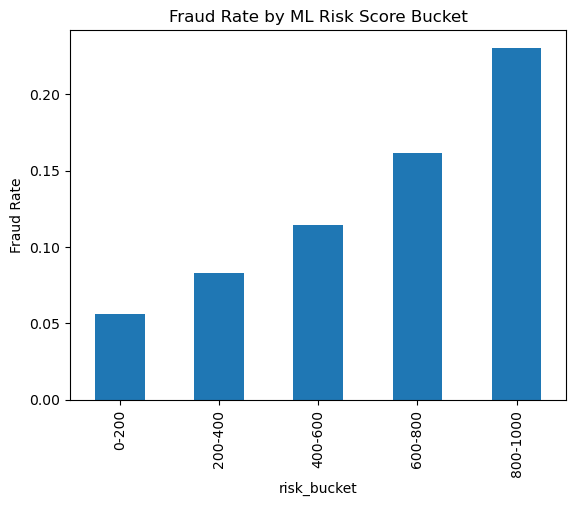

In [5]:
bucket_analysis["fraud_rate"].plot(kind="bar")

plt.title("Fraud Rate by ML Risk Score Bucket")
plt.ylabel("Fraud Rate")
plt.show()

## Approval Threshold Optimization

In [6]:
thresholds = range(300, 901, 50)

results = []

for threshold in thresholds:
    approved = df[df["ml_risk_score"] < threshold]

    results.append({
        "threshold": threshold,
        "approval_rate": len(approved) / len(df),
        "fraud_rate": approved["is_fraud"].mean(),
        "losses": approved["loss_amount"].sum()
    })

threshold_df = pd.DataFrame(results)

threshold_df

,threshold,approval_rate,fraud_rate,losses
0,300,0.10502,0.068558,8.882687e+04
1,350,0.18706,0.074522,1.685168e+05
2,400,0.29798,0.080878,2.901709e+05
3,450,0.42862,0.087257,4.517218e+05
4,500,0.56668,0.091163,6.275002e+05
5,550,0.69790,0.096633,8.166260e+05
6,600,0.80630,0.101823,9.908743e+05
7,650,0.89006,0.106914,1.146232e+06
8,700,0.94364,0.110212,1.252197e+06
9,750,0.97590,0.112122,1.311634e+06


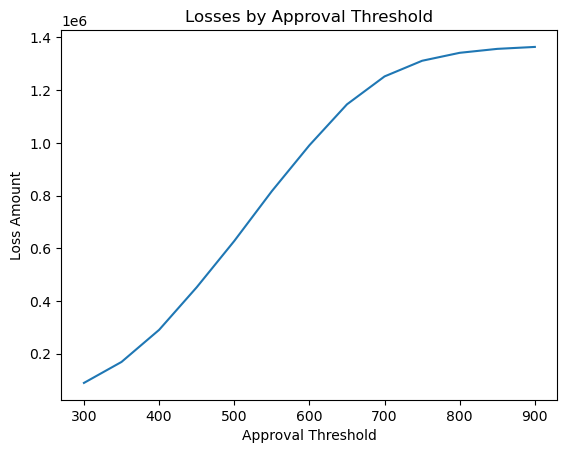

In [7]:
plt.plot(threshold_df["threshold"], threshold_df["losses"])

plt.title("Losses by Approval Threshold")
plt.xlabel("Approval Threshold")
plt.ylabel("Loss Amount")
plt.show()

## Customer Cohort Analysis

In [8]:
df["customer_tenure_bucket"] = pd.cut(
    df["customer_age_days"],
    bins=[0, 30, 90, 180, 365, 10000],
    labels=["0-30", "30-90", "90-180", "180-365", "365+"]
)

cohort_analysis = df.groupby("customer_tenure_bucket").agg({
    "is_fraud": "mean",
    "loss_amount": "mean",
    "transaction_amount": "mean"
})

cohort_analysis

C:\Users\sered\AppData\Local\Temp\ipykernel_24132\4204931695.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_analysis = df.groupby("customer_tenure_bucket").agg({


,is_fraud,loss_amount,transaction_amount
customer_tenure_bucket,,,
0-30,0.113668,26.838727,297.142007
30-90,0.119422,27.841020,301.221914
90-180,0.109898,26.308444,302.410586
180-365,0.112799,27.262280,300.586921
365+,0.114572,27.658801,301.576977


## Fraud Detection Model: Random Forest

In [9]:
features = [
    "transaction_amount",
    "transactions_30d",
    "chargebacks_90d",
    "device_risk_score",
    "velocity_score",
    "vendor_risk_score",
    "geo_risk_score",
    "customer_age_days",
    "bank_account_age_days"
]

X = df[features]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

pred_probs = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, pred_probs)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.6216


## Optimize ML model hyperparameter

In [10]:
nes = [] # n_estimators optimized hyperparameter
aucs = []
for ne in range(10,300+1,10):
    model = RandomForestClassifier(
        n_estimators=ne,
        max_depth=8,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred_probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, pred_probs)
    nes.append(ne); aucs.append(auc);
print(nes,aucs)
idx_opt = np.argmax(aucs)
n_estimators_opt = nes[idx_opt]
print("Optimal number of trees:", n_estimators_opt)
print("Max ROC-AUC:", aucs[idx_opt])

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300] [np.float64(0.6168490065036889), np.float64(0.6162110558870542), np.float64(0.6192256138255854), np.float64(0.6194469466460373), np.float64(0.6196895510523477), np.float64(0.6199942468238617), np.float64(0.621070628460141), np.float64(0.620493045816337), np.float64(0.6210310396753483), np.float64(0.6216386585862215), np.float64(0.6217714090387105), np.float64(0.6220359251480467), np.float64(0.6219694514422383), np.float64(0.6219459148264037), np.float64(0.6224176319387346), np.float64(0.6224740607289989), np.float64(0.6226610734213406), np.float64(0.6225767749144188), np.float64(0.6231071858469899), np.float64(0.6230854218633103), np.float64(0.6232525416836912), np.float64(0.6232070441250489), np.float64(0.6233877541252844), np.float64(0.6229459748004583), np.float64(0.6224834162875942), np.float64(0.6227779686639996), np.float64(0.62263123411339

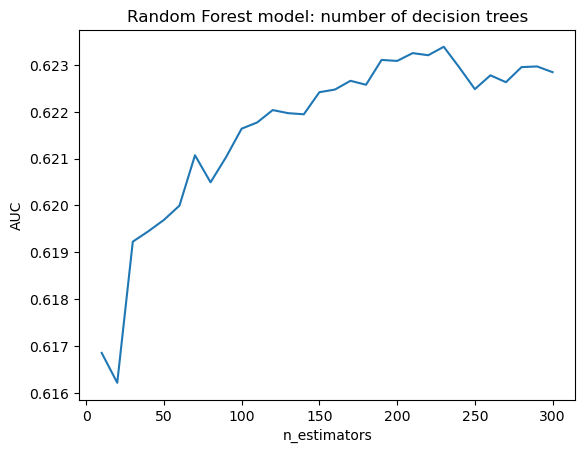

In [18]:
nes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300];
aucs = [0.6168490065036889, 0.6162110558870542, 0.6192256138255854, 0.6194469466460373, 0.6196895510523477, 0.6199942468238617, 0.621070628460141, 0.620493045816337, 0.6210310396753483, 0.6216386585862215, 0.6217714090387105, 0.6220359251480467, 0.6219694514422383, 0.6219459148264037, 0.6224176319387346, 0.6224740607289989, 0.6226610734213406, 0.6225767749144188, 0.6231071858469899, 0.6230854218633103, 0.6232525416836912, 0.6232070441250489, 0.6233877541252844, 0.6229459748004583, 0.6224834162875942, 0.6227779686639996, 0.6226312341133998, 0.6229534592473345, 0.6229679357432661, 0.6228454271654499];
plt.plot(nes,aucs)
plt.title("Random Forest model: number of decision trees")
plt.xlabel('n_estimators')
plt.ylabel('AUC');

In [12]:
mds = [] # max_depth optimized
aucs = []
for md in range(1,20+1):
    model = RandomForestClassifier(
        n_estimators=n_estimators_opt,
        max_depth=md,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred_probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, pred_probs)
    mds.append(md); aucs.append(auc);
print(mds,aucs)
idx_opt = np.argmax(aucs)
max_depth_opt = mds[idx_opt]
print("Optimal tree depth:", max_depth_opt)
print("Max ROC-AUC:", aucs[idx_opt])

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] [np.float64(0.6242859862299965), np.float64(0.6234602843242889), np.float64(0.6236785150384695), np.float64(0.6235755546541394), np.float64(0.6252529570704929), np.float64(0.6233081826374423), np.float64(0.6245050047806905), np.float64(0.6233877541252844), np.float64(0.6227577803533466), np.float64(0.6230819750785646), np.float64(0.6226677700317036), np.float64(0.618708300675048), np.float64(0.6186142526912741), np.float64(0.6184940091434336), np.float64(0.6207907495387956), np.float64(0.6157821773851332), np.float64(0.6091987200414087), np.float64(0.6152926354716891), np.float64(0.610400466162865), np.float64(0.6097686212792082)]
Optimal tree depth: 5
Max ROC-AUC: 0.6252529570704929


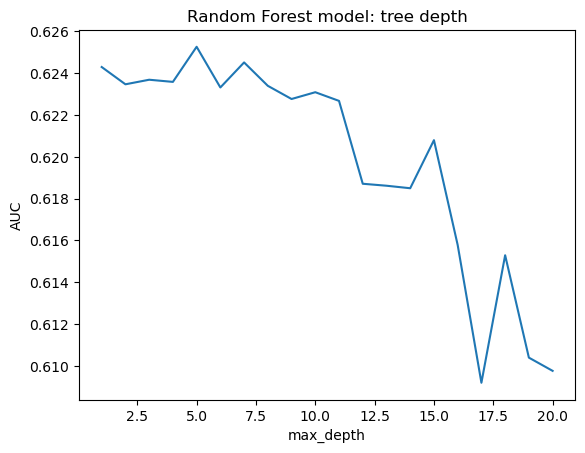

In [19]:
mds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20];
aucs = [0.6242859862299965, 0.6234602843242889, 0.6236785150384695, 0.6235755546541394, 0.6252529570704929, 0.6233081826374423, 0.6245050047806905, 0.6233877541252844, 0.6227577803533466, 0.6230819750785646, 0.6226677700317036, 0.618708300675048, 0.6186142526912741, 0.6184940091434336, 0.6207907495387956, 0.6157821773851332, 0.6091987200414087, 0.6152926354716891, 0.610400466162865, 0.6097686212792082];
plt.plot(mds,aucs)
plt.title("Random Forest model: tree depth")
plt.xlabel('max_depth')
plt.ylabel('AUC');

In [20]:
# Retrain with optimal hyperparameters
model = RandomForestClassifier(
    n_estimators=n_estimators_opt, max_depth=max_depth_opt,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=230, random_state=42)

## Feature Importance

In [21]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
2,chargebacks_90d,0.532525
4,velocity_score,0.090892
3,device_risk_score,0.081054
5,vendor_risk_score,0.075432
6,geo_risk_score,0.072947
0,transaction_amount,0.049512
8,bank_account_age_days,0.044791
7,customer_age_days,0.032633
1,transactions_30d,0.020216


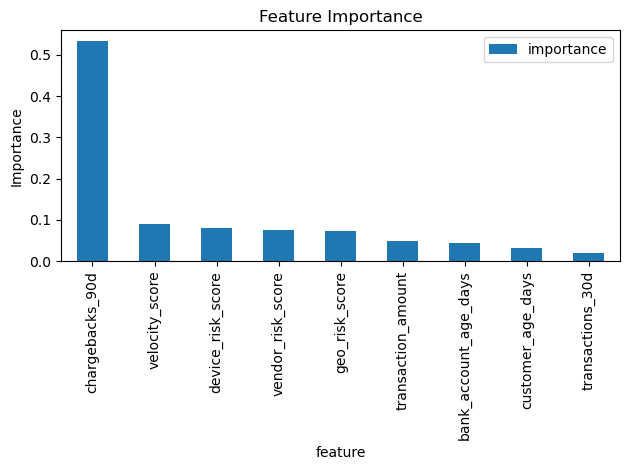

In [22]:
importance_df.plot(
    x="feature",
    y="importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Prediction

In [23]:
X_input = pd.DataFrame([[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]], columns = X_train.columns)
display(X_input)
print( model.predict(X_input) )

,transaction_amount,transactions_30d,chargebacks_90d,device_risk_score,velocity_score,vendor_risk_score,geo_risk_score,customer_age_days,bank_account_age_days
0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9


[0]



# Key Takeaways

This project demonstrates experience with:

- ACH payment analytics
- Risk scoring systems
- Fraud detection workflows
- Portfolio monitoring
- Python-based data analysis
- ML model evaluation
- Decision strategy optimization
- Cohort and trend analysis
- Production-style analytical workflows
- Risk analytics communication and reporting

The notebook is intentionally structured to mirror the analytical responsibilities commonly found in fintech payment risk and fraud intelligence teams.
